In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("../data/PreProcessed_IBM_Telco_Customer_Churn_Cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,1


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 23)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
Te

In [6]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureGroup         0
TotalServices       0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


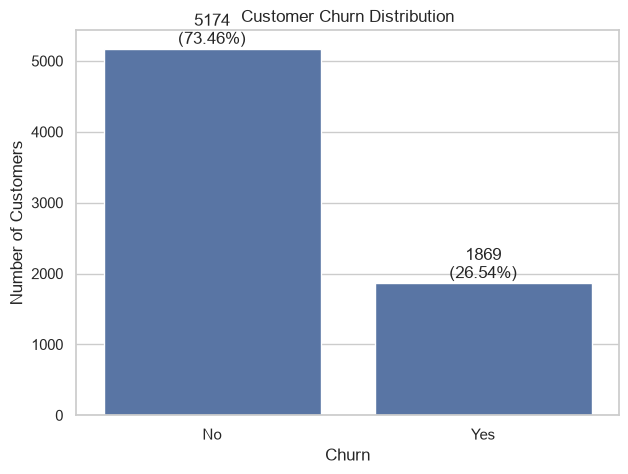

In [11]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="Churn")

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100
    ax.annotate(
        f"{count}\n({percentage:.2f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

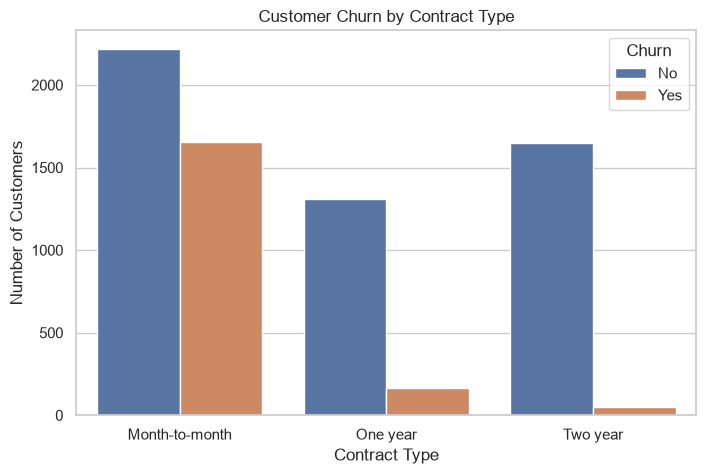

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

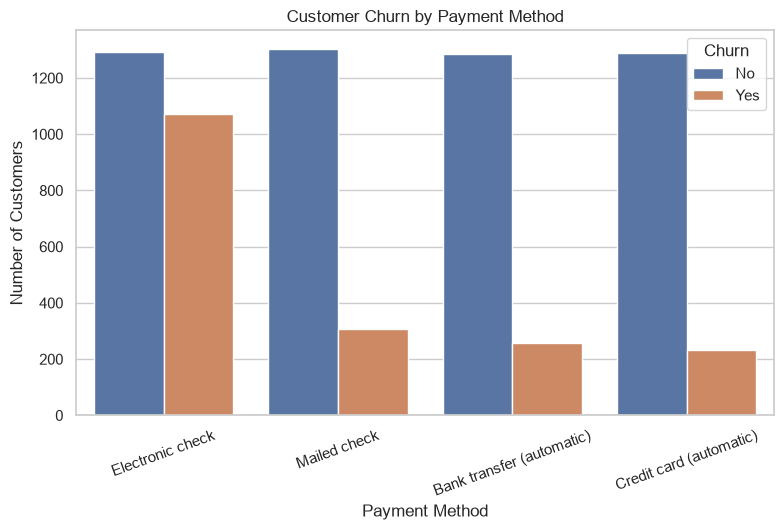

In [13]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

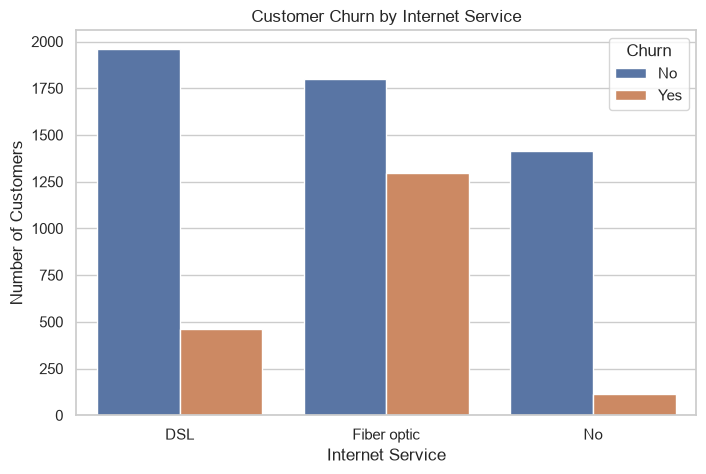

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

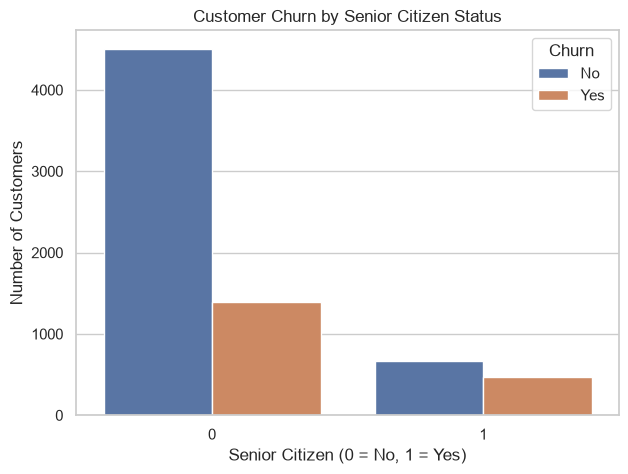

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

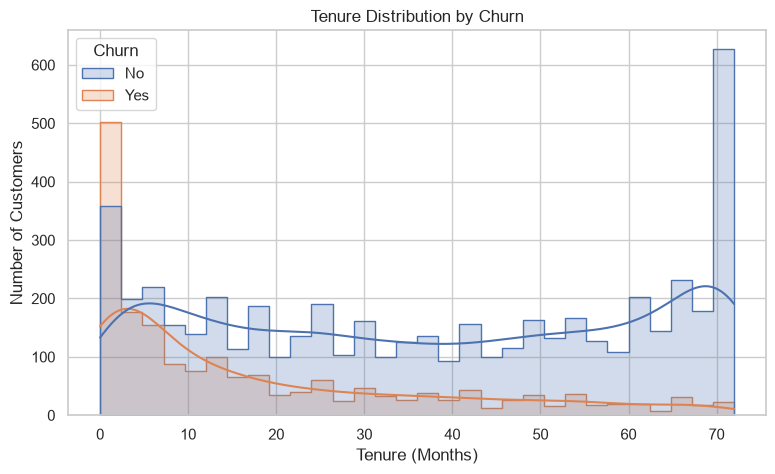

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

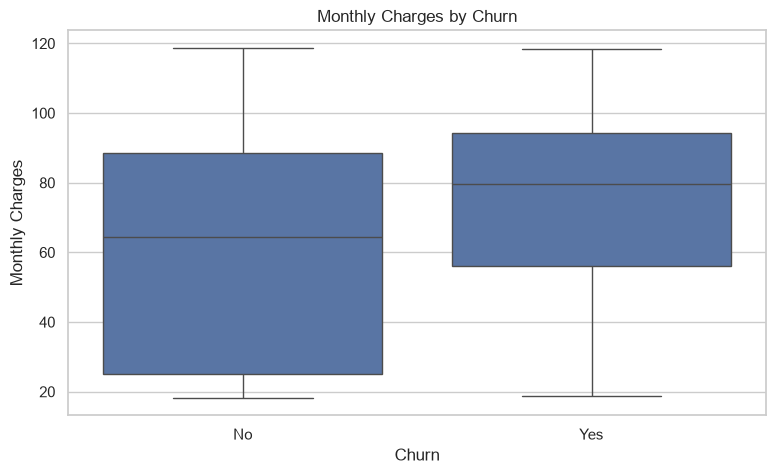

In [17]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

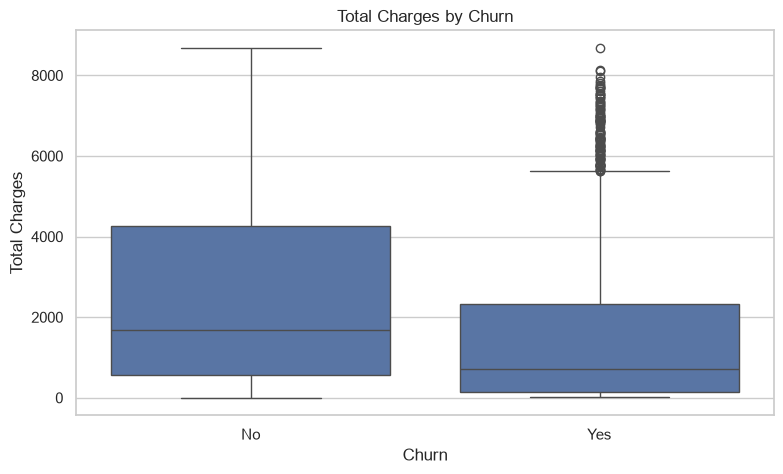

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

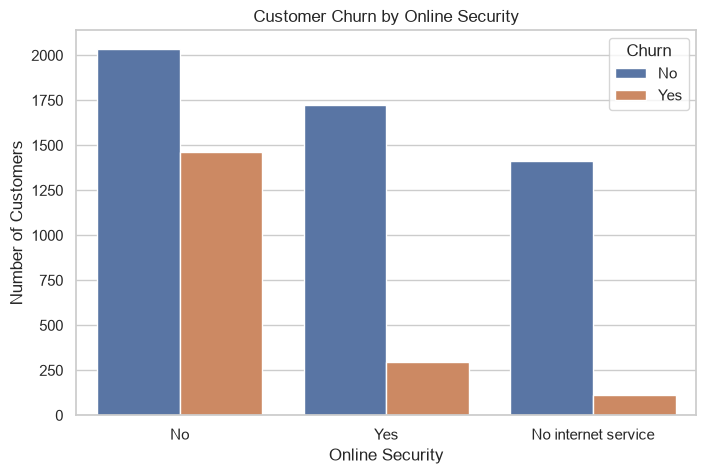

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

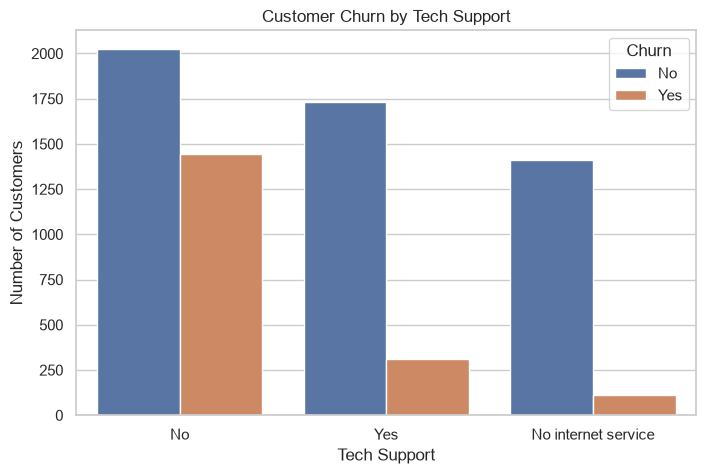

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

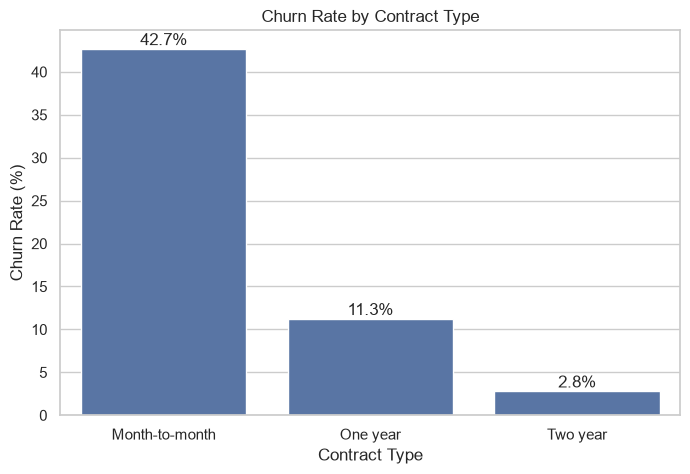

In [21]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_churn_rate,
    x="Contract",
    y="ChurnRate"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [22]:
# Create tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Calculate churn rate for each tenure group
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

tenure_churn_rate

,TenureGroup,ChurnRate
0,0-12 Months,47.438243
1,13-24 Months,28.710938
2,25-48 Months,20.388959
3,49-72 Months,9.513176


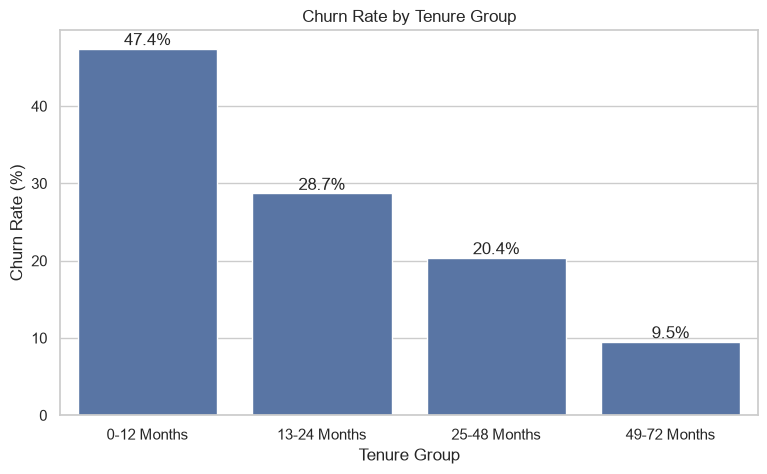

In [23]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_churn_rate,
    x="TenureGroup",
    y="ChurnRate"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

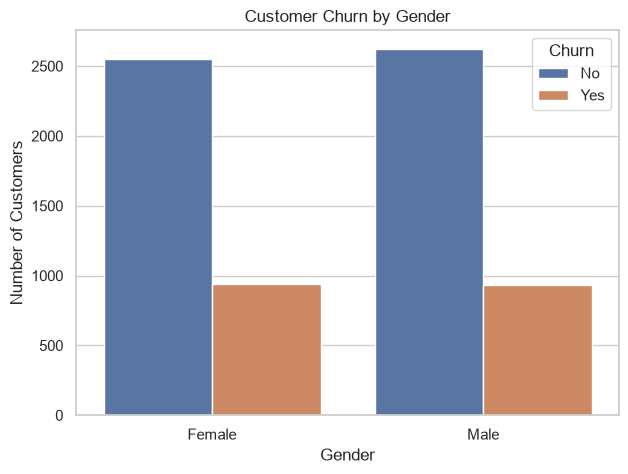

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

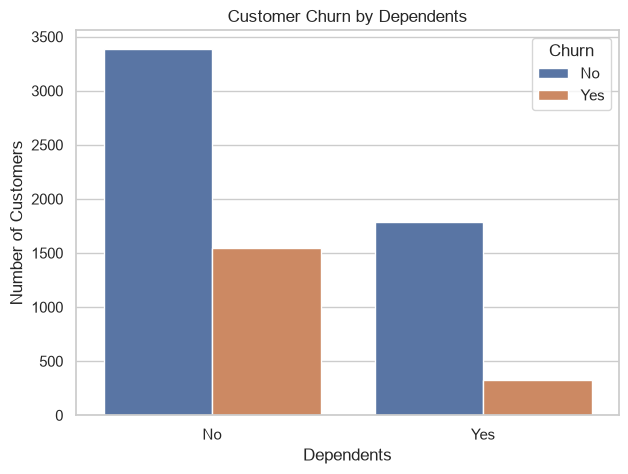

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Dependents", hue="Churn")

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

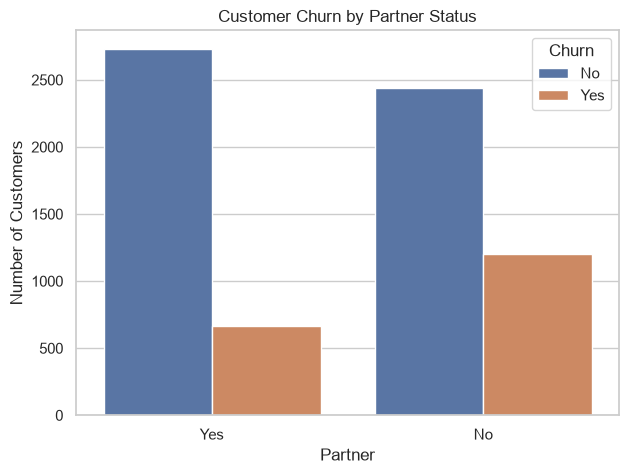

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

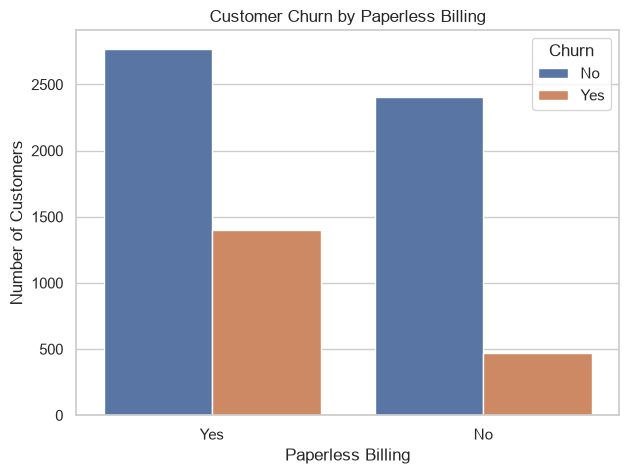

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

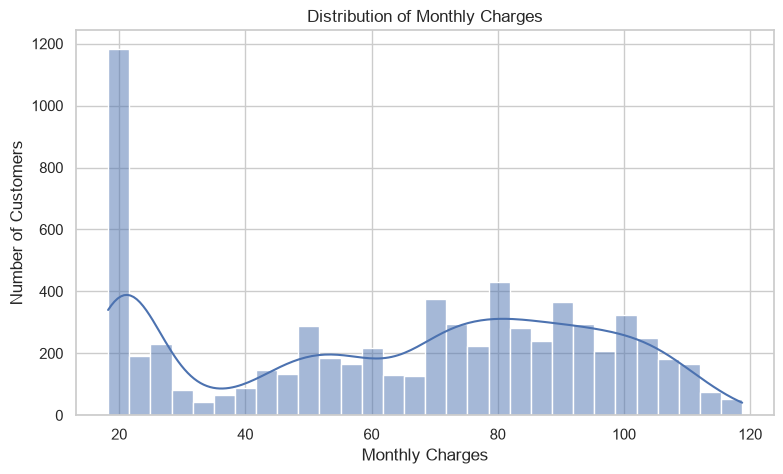

In [28]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

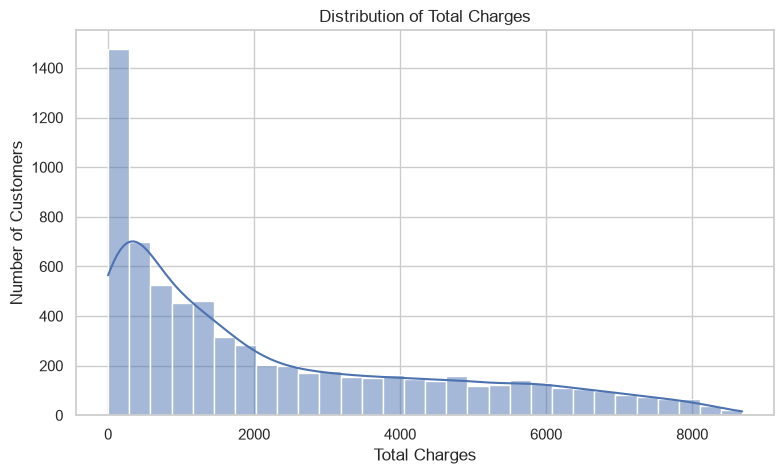

In [29]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

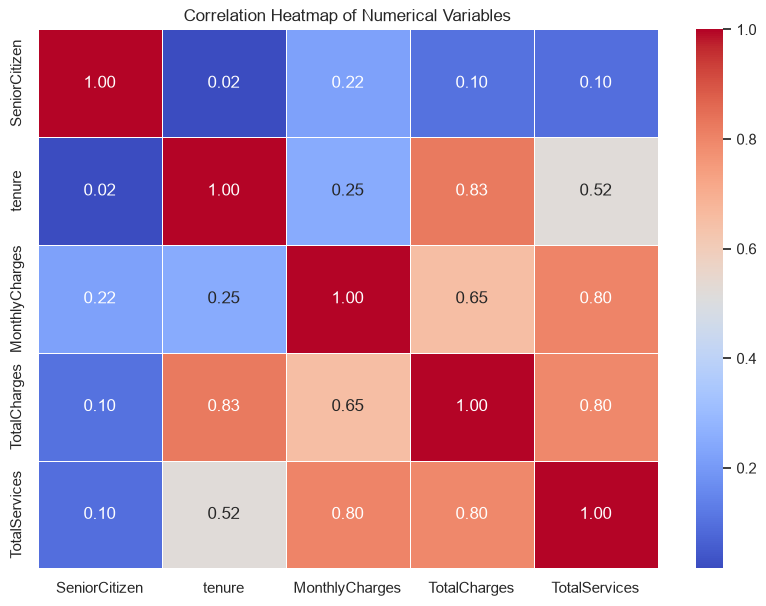

In [30]:
# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

## EDA Key Insights

### 1. Overall Churn
- The dataset contains 7,043 customers.
- 1,869 customers have churned, representing 26.54%.
- 5,174 customers have not churned, representing 73.46%.

### 2. Contract Type and Churn
- Month-to-month customers show the highest churn.
- Customers with one-year and two-year contracts show comparatively lower churn.
- Contract type is an important factor associated with customer churn.

### 3. Tenure and Churn
- Customer churn varies across different tenure groups.
- Customers with shorter tenure generally show higher churn.
- Longer-tenure customers generally show lower churn.

### 4. Payment Method and Churn
- Electronic check customers show a comparatively high level of churn.
- Customers using automatic payment methods show comparatively lower churn.

### 5. Internet Service and Churn
- Churn differs across different internet service categories.
- Internet service type appears to be associated with customer churn.

### 6. Monthly Charges and Churn
- Monthly charges show different distributions between churned and non-churned customers.
- Monthly charges should be considered when analyzing customer churn behavior.

### 7. Total Charges and Churn
- Total charges vary between churned and non-churned customers.
- Total charges are related to customer tenure and should be considered together with tenure.

### 8. Customer Services and Churn
- Online security and technical support show differences in churn patterns.
- Service-related features can provide useful signals for understanding customer retention.

### 9. Overall Observation
- Contract type, tenure, payment method, internet service, charges, and customer services show meaningful relationships with churn.
- These findings can be used as a baseline for the next stages of the project.